In [1]:
# Jupyter Notebook - 代码

# 导入必要的库
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# 设定日志级别，减少不必要的输出
tf.get_logger().setLevel('ERROR')


# 🔹 超参数

IMG_SIZE = (128, 128)
AUTOTUNE = tf.data.AUTOTUNE

第一阶段训练 ， 载入原数据集不使用任何数据增强

In [2]:
# 🔹 数据集路径
base_dir = './dataset'
train_dir = os.path.join(base_dir, 'Origin')
valid_dir = os.path.join(base_dir, 'Origin')

BATCH_SIZE = 128
# 🔹 加载数据集
train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=12,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)  # ✅ batch_size 已经指定

validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, validation_split=0.2, subset="validation", seed=12,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)  # ✅ batch_size 已经指定

class_names = train_dataset_raw.class_names
print("Class Names:", class_names)


# 预处理函数
def preprocess_image(image, label):
    # image = tf.image.convert_image_dtype(image, tf.uint8)  # 归一化
    return image, label

def preprocess_image2(image, label):
    # image = tf.image.convert_image_dtype(image, tf.uint8)  # 归一化
    return image, label

# 加载数据集 & 预处理
train_dataset = (train_dataset_raw
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .shuffle(1000)
                 .prefetch(AUTOTUNE))  # ✅ 不再 batch()

validation_dataset = (validation_dataset_raw
                      .map(preprocess_image2, num_parallel_calls=AUTOTUNE)
                      .cache()
                      .prefetch(AUTOTUNE))  # ✅ 不再 batch()

Found 3053 files belonging to 15 classes.
Using 2443 files for training.
Found 3053 files belonging to 15 classes.
Using 610 files for validation.
Class Names: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o']


In [3]:
# 🔹 预训练模型（MobileNet）
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNet(
    input_shape=IMG_SHAPE, include_top=False, alpha=0.25, weights='imagenet')

# 仅微调最后4层
base_model.trainable = True
for layer in base_model.layers[:-0]:
    layer.trainable = False

base_model.summary()

# 🔹 构建模型
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),  # 归一化到 [0,1]
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),  # Dropout 防止过拟合
    tf.keras.layers.Dense(len(class_names), activation='softmax')  # 分类层
])
model.build((None, 128, 128, 3))
model.summary()

Model: "mobilenet_0.25_128"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 64, 64, 8)         216       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 64, 64, 8)        32        
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 64, 64, 8)         0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 8)        72        
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 64, 64, 8)        32        
 ation)                                         

In [4]:
# 🔹 指数学习率衰减
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001, decay_steps=10000, decay_rate=0.90, staircase=True)

# 编译模型
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# 训练回调（去掉 ReduceLROnPlateau）
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [ ]:
# 训练模型
history = model.fit(train_dataset, validation_data=validation_dataset,
                    epochs=100, callbacks=[early_stopping])

Epoch 1/25
20/20 [==============================] - 1s 73ms/step - loss: 0.1146 - accuracy: 0.9652 - val_loss: 0.2947 - val_accuracy: 0.9115
Epoch 2/25
20/20 [==============================] - 1s 63ms/step - loss: 0.1142 - accuracy: 0.9623 - val_loss: 0.2935 - val_accuracy: 0.9148
Epoch 3/25
20/20 [==============================] - 1s 63ms/step - loss: 0.1049 - accuracy: 0.9738 - val_loss: 0.2927 - val_accuracy: 0.9180
Epoch 4/25
20/20 [==============================] - 1s 61ms/step - loss: 0.1033 - accuracy: 0.9713 - val_loss: 0.2943 - val_accuracy: 0.9148
Epoch 5/25
20/20 [==============================] - 1s 61ms/step - loss: 0.0903 - accuracy: 0.9771 - val_loss: 0.2977 - val_accuracy: 0.9230
Epoch 6/25
20/20 [==============================] - 1s 61ms/step - loss: 0.0938 - accuracy: 0.9754 - val_loss: 0.2966 - val_accuracy: 0.9164
Epoch 7/25
20/20 [==============================] - 1s 63ms/step - loss: 0.0894 - accuracy: 0.9767 - val_loss: 0.2943 - val_accuracy: 0.9180
Epoch 8/25
20

第二阶段训练 ， 加载数据增强数据集进行训练

In [9]:
# 🔹 数据集路径
base_dir = './dataset'
train_dir = os.path.join(base_dir, 'YASUO_80')
valid_dir = os.path.join(base_dir, 'YASUO_80')

BATCH_SIZE = 64

# 🔹 加载数据集
train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=21,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)  # ✅ batch_size 已经指定

validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, validation_split=0.2, subset="validation", seed=21,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)  # ✅ batch_size 已经指定

class_names = train_dataset_raw.class_names
print("Class Names:", class_names)

# 预处理函数
def preprocess_image(image, label):
    # image = tf.image.convert_image_dtype(image, tf.uint8)  # 归一化
    return image, label

def preprocess_image2(image, label):
    # image = tf.image.convert_image_dtype(image, tf.uint8)  # 归一化
    return image, label

# 加载数据集 & 预处理
train_dataset = (train_dataset_raw
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .shuffle(1000)
                 .prefetch(AUTOTUNE))  # ✅ 不再 batch()

validation_dataset = (validation_dataset_raw
                      .map(preprocess_image2, num_parallel_calls=AUTOTUNE)
                      .cache()
                      .prefetch(AUTOTUNE))  # ✅ 不再 batch()

Found 24424 files belonging to 15 classes.
Using 19540 files for training.
Found 24424 files belonging to 15 classes.
Using 4884 files for validation.
Class Names: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o']


In [10]:
# 🔹 指数学习率衰减
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001, decay_steps=10000, decay_rate=0.90, staircase=True)

# 编译模型
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# 训练回调（去掉 ReduceLROnPlateau）
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# 训练模型
history = model.fit(train_dataset, validation_data=validation_dataset,
                    epochs=100, callbacks=[early_stopping])

Epoch 1/25
306/306 [==============================] - 12s 37ms/step - loss: 0.0261 - accuracy: 0.9927 - val_loss: 0.0722 - val_accuracy: 0.9734
Epoch 2/25
306/306 [==============================] - 11s 35ms/step - loss: 0.0239 - accuracy: 0.9941 - val_loss: 0.0715 - val_accuracy: 0.9760
Epoch 3/25
306/306 [==============================] - 11s 35ms/step - loss: 0.0218 - accuracy: 0.9939 - val_loss: 0.0757 - val_accuracy: 0.9756
Epoch 4/25
306/306 [==============================] - 11s 35ms/step - loss: 0.0186 - accuracy: 0.9955 - val_loss: 0.0707 - val_accuracy: 0.9765
Epoch 5/25
306/306 [==============================] - 11s 35ms/step - loss: 0.0161 - accuracy: 0.9959 - val_loss: 0.0795 - val_accuracy: 0.9734
Epoch 6/25
306/306 [==============================] - 11s 35ms/step - loss: 0.0161 - accuracy: 0.9955 - val_loss: 0.0807 - val_accuracy: 0.9722
Epoch 7/25
306/306 [==============================] - 11s 35ms/step - loss: 0.0145 - accuracy: 0.9959 - val_loss: 0.0722 - val_accuracy:

In [15]:
# 🔹 数据集路径
base_dir = './dataset'
train_dir = os.path.join(base_dir, 'Cont')
valid_dir = os.path.join(base_dir, 'Cont')

BATCH_SIZE = 32

# 🔹 加载数据集
train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=21,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)  # ✅ batch_size 已经指定

validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, validation_split=0.2, subset="validation", seed=21,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)  # ✅ batch_size 已经指定

class_names = train_dataset_raw.class_names
print("Class Names:", class_names)

# 预处理函数
def preprocess_image(image, label):
    # image = tf.image.convert_image_dtype(image, tf.uint8)  # 归一化
    return image, label

def preprocess_image2(image, label):
    # image = tf.image.convert_image_dtype(image, tf.uint8)  # 归一化
    return image, label

# 加载数据集 & 预处理
train_dataset = (train_dataset_raw
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .shuffle(1000)
                 .prefetch(AUTOTUNE))  # ✅ 不再 batch()

validation_dataset = (validation_dataset_raw
                      .map(preprocess_image2, num_parallel_calls=AUTOTUNE)
                      .cache()
                      .prefetch(AUTOTUNE))  # ✅ 不再 batch()

Found 48848 files belonging to 15 classes.
Using 39079 files for training.
Found 48848 files belonging to 15 classes.
Using 9769 files for validation.
Class Names: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o']


In [16]:
# 🔹 指数学习率衰减
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001, decay_steps=10000, decay_rate=0.90, staircase=True)

# 编译模型
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# 训练回调（去掉 ReduceLROnPlateau）
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [17]:
# 训练模型
history = model.fit(train_dataset, validation_data=validation_dataset,
                    epochs=100, callbacks=[early_stopping])

Epoch 1/25
1222/1222 [==============================] - 47s 29ms/step - loss: 0.1977 - accuracy: 0.9402 - val_loss: 0.0748 - val_accuracy: 0.9784
Epoch 2/25
1222/1222 [==============================] - 31s 26ms/step - loss: 0.1238 - accuracy: 0.9588 - val_loss: 0.0644 - val_accuracy: 0.9790
Epoch 3/25
1222/1222 [==============================] - 31s 26ms/step - loss: 0.0970 - accuracy: 0.9680 - val_loss: 0.0646 - val_accuracy: 0.9799
Epoch 4/25
1222/1222 [==============================] - 31s 26ms/step - loss: 0.0745 - accuracy: 0.9753 - val_loss: 0.0609 - val_accuracy: 0.9809
Epoch 5/25
1222/1222 [==============================] - 31s 26ms/step - loss: 0.0615 - accuracy: 0.9804 - val_loss: 0.0736 - val_accuracy: 0.9779
Epoch 6/25
1222/1222 [==============================] - 32s 26ms/step - loss: 0.0540 - accuracy: 0.9824 - val_loss: 0.0587 - val_accuracy: 0.9818
Epoch 7/25
1222/1222 [==============================] - 31s 25ms/step - loss: 0.0430 - accuracy: 0.9866 - val_loss: 0.0507 -

第三阶段 ， 启用自动数据增强

In [18]:
# 🔹 数据增强
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.125),
    tf.keras.layers.RandomZoom(0.5),
    tf.keras.layers.RandomTranslation(height_factor=0.25, width_factor=0.25),
    tf.keras.layers.RandomBrightness(0.25),
    tf.keras.layers.RandomContrast(0.5)
])

# 预处理函数
def preprocess_image(image, label):
    image = data_augmentation(image)  # 添加数据增强
    # image = tf.image.convert_image_dtype(image, tf.uint8)  # 归一化
    return image, label

def preprocess_image2(image, label):
    # image = tf.image.convert_image_dtype(image, tf.uint8)  # 归一化
    return image, label

# 加载数据集 & 预处理
train_dataset = (train_dataset_raw
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .shuffle(1000)
                 .prefetch(AUTOTUNE))  # ✅ 不再 batch()

validation_dataset = (validation_dataset_raw
                      .map(preprocess_image2, num_parallel_calls=AUTOTUNE)
                      .cache()
                      .prefetch(AUTOTUNE))  # ✅ 不再 batch()

In [19]:
# 🔹 指数学习率衰减
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001, decay_steps=10000, decay_rate=0.90, staircase=True)

# 编译模型
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# 训练回调（去掉 ReduceLROnPlateau）
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [20]:
# 训练模型
history = model.fit(train_dataset, validation_data=validation_dataset,
                    epochs=100, callbacks=[early_stopping])

Epoch 1/100
1222/1222 [==============================] - 47s 29ms/step - loss: 0.0765 - accuracy: 0.9742 - val_loss: 0.0505 - val_accuracy: 0.9839
Epoch 2/100
1222/1222 [==============================] - 32s 26ms/step - loss: 0.0545 - accuracy: 0.9818 - val_loss: 0.0476 - val_accuracy: 0.9846
Epoch 3/100
1222/1222 [==============================] - 32s 26ms/step - loss: 0.0435 - accuracy: 0.9857 - val_loss: 0.0471 - val_accuracy: 0.9851
Epoch 4/100
1222/1222 [==============================] - 32s 26ms/step - loss: 0.0351 - accuracy: 0.9887 - val_loss: 0.0466 - val_accuracy: 0.9855
Epoch 5/100
1222/1222 [==============================] - 32s 26ms/step - loss: 0.0333 - accuracy: 0.9888 - val_loss: 0.0490 - val_accuracy: 0.9854
Epoch 6/100
1222/1222 [==============================] - 32s 26ms/step - loss: 0.0286 - accuracy: 0.9907 - val_loss: 0.0505 - val_accuracy: 0.9846
Epoch 7/100
1222/1222 [==============================] - 32s 26ms/step - loss: 0.0235 - accuracy: 0.9926 - val_loss: 0

In [21]:
def representative_dataset():
    for image_batch, _ in tqdm(train_dataset.take(5000), total=5000, desc="Processing"):
        yield [tf.cast(image_batch[0:1], tf.float32)]  # 仅返回单张图片

# 🔹 量化模型为 TFLite INT8
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8
tflite_model_quant = converter.convert()

# 🔹 保存 TFLite 量化模型
os.makedirs('./model', exist_ok=True)
with open('./model/mnist_model_quant_uint8.tflite', "wb") as f:
    f.write(tflite_model_quant)

# 🔹 推理测试（检查 TFLite 输入输出类型）
interpreter = tf.lite.Interpreter(model_content=tflite_model_quant)
print('Input Type:', interpreter.get_input_details()[0]['dtype'])
print('Output Type:', interpreter.get_output_details()[0]['dtype'])

d:\miniconda\envs\tf\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
Processing:  24%|██▍       | 1222/5000 [00:18<00:58, 64.46it/s]


Input Type: <class 'numpy.uint8'>
Output Type: <class 'numpy.uint8'>


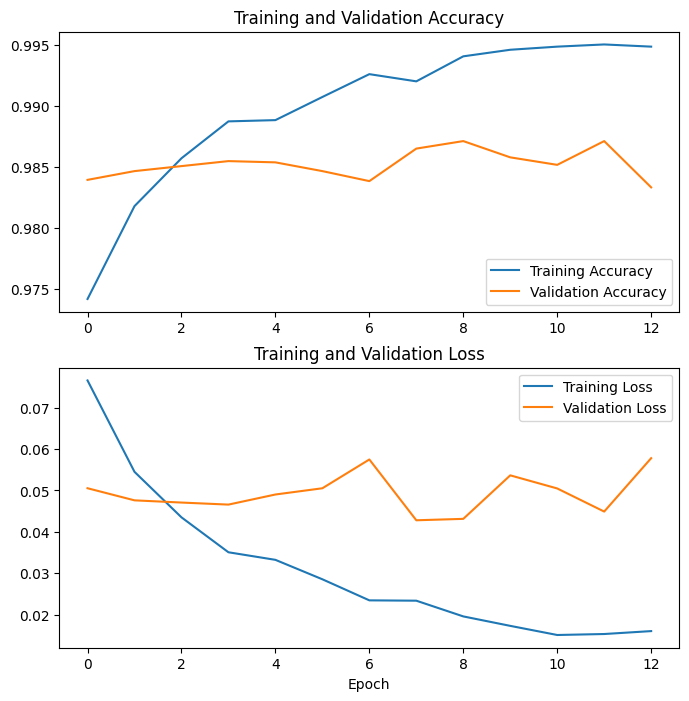

In [22]:
# 🔹 训练曲线可视化
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.show()


306/306 [==============================] - 3s 9ms/step


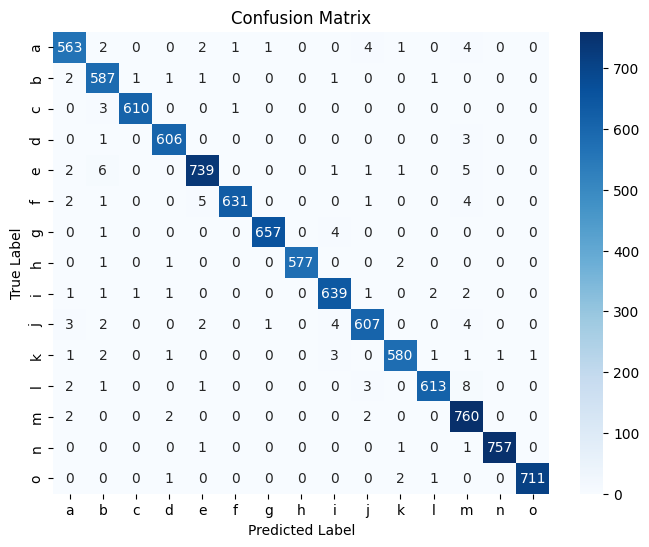

In [23]:
# 🔹 混淆矩阵（分析分类错误）
y_pred = np.argmax(model.predict(validation_dataset), axis=1)
y_true = np.concatenate([labels.numpy() for _, labels in validation_dataset])

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
